Dataset shape: (6607, 7)
   Hours_Studied  Attendance  Sleep_Hours  Previous_Scores  Tutoring_Sessions  \
0             23          84            7               73                  0   
1             19          64            8               59                  2   
2             24          98            7               91                  2   
3             29          89            8               98                  1   
4             19          92            6               65                  3   

   Physical_Activity  Exam_Score  
0                  3          67  
1                  4          61  
2                  4          74  
3                  4          71  
4                  4          70  

Median Exam Score: 67.0

Label counts:
Label
1    3725
0    2882
Name: count, dtype: int64

Training shape: (4955, 6)
Testing shape: (1652, 6)

Logistic Regression
Accuracy: 0.8620

Classification Report:
              precision    recall  f1-score   support

           0     

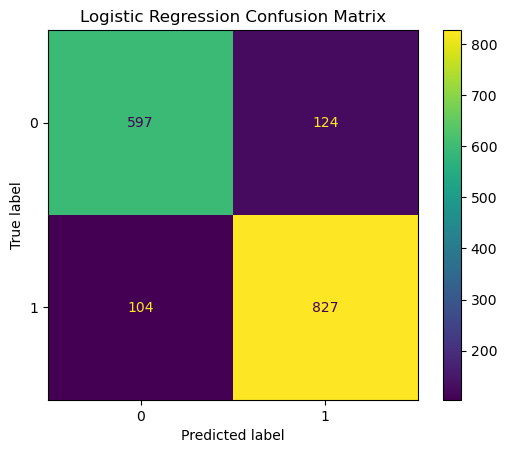


SVM
Accuracy: 0.8559

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.81      0.83       721
           1       0.86      0.89      0.87       931

    accuracy                           0.86      1652
   macro avg       0.86      0.85      0.85      1652
weighted avg       0.86      0.86      0.86      1652



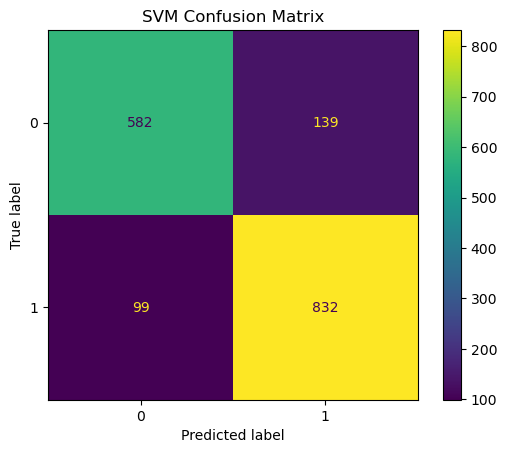


Random Forest
Accuracy: 0.8553

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.81      0.83       721
           1       0.86      0.89      0.87       931

    accuracy                           0.86      1652
   macro avg       0.85      0.85      0.85      1652
weighted avg       0.86      0.86      0.85      1652



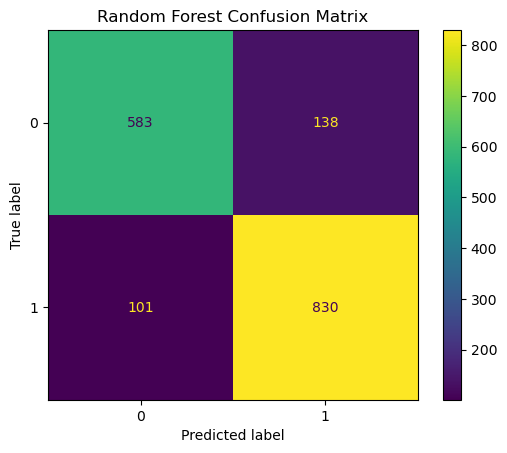


Model Comparison:
                 Model  Accuracy
0  Logistic Regression  0.861985
1                  SVM  0.855932
2        Random Forest  0.855327


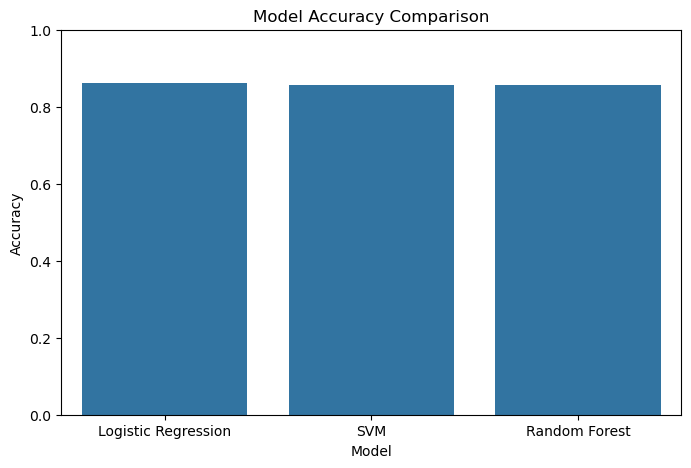

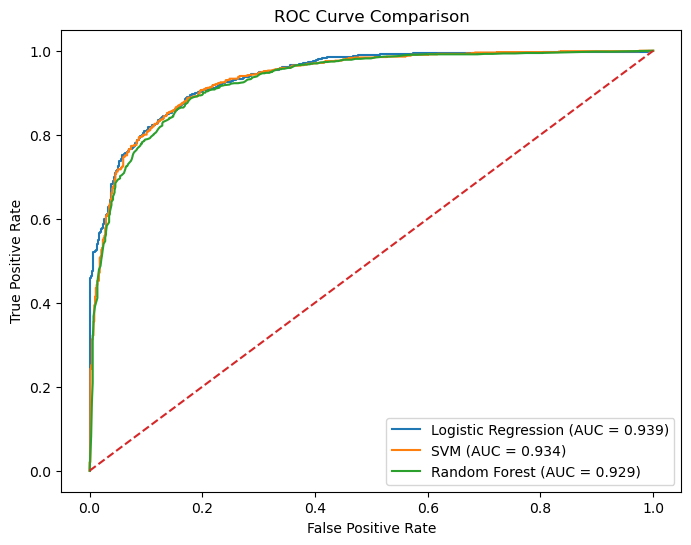


Random Forest Feature Importance:
             Feature  Importance
5  Physical_Activity    0.050231
4  Tutoring_Sessions    0.055690
2        Sleep_Hours    0.060659
3    Previous_Scores    0.136360
0      Hours_Studied    0.253943
1         Attendance    0.443118


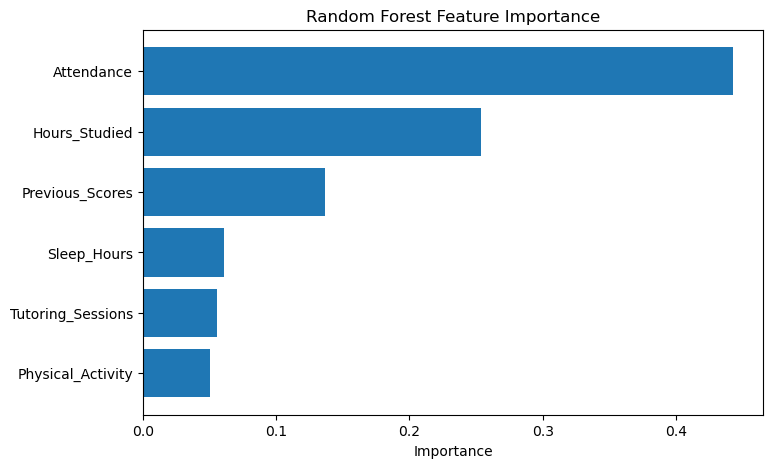

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    auc
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier


# LOAD DATA

df = pd.read_csv("dataset1_cleaned_numeric.csv")

print("Dataset shape:", df.shape)
print(df.head())

# Create binary label from Exam_Score
median_score = df["Exam_Score"].median()
df["Label"] = (df["Exam_Score"] >= median_score).astype(int)

print("\nMedian Exam Score:", median_score)
print("\nLabel counts:")
print(df["Label"].value_counts())


# SELECT FEATURES

features = [
    "Hours_Studied",
    "Attendance",
    "Sleep_Hours",
    "Previous_Scores",
    "Tutoring_Sessions",
    "Physical_Activity"
]

X = df[features]
y = df["Label"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("\nTraining shape:", X_train.shape)
print("Testing shape:", X_test.shape)


# DEFINE MODELS

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, random_state=42))
    ]),
    
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", C=0.1, probability=True, random_state=42))
    ]),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        random_state=42
    )
}


# TRAIN AND EVALUATE MODELS

results = []

for name, model in models.items():
    print("\n" + "="*50)
    print(name)
    print("="*50)
    
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, preds)
    results.append([name, acc])
    
    print(f"Accuracy: {acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, preds))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"{name} Confusion Matrix")
    plt.show()


#  COMPARE ACCURACY

results_df = pd.DataFrame(results, columns=["Model", "Accuracy"])
print("\nModel Comparison:")
print(results_df.sort_values("Accuracy", ascending=False))

plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x="Model", y="Accuracy")
plt.title("Model Accuracy Comparison")
plt.ylim(0, 1)
plt.show()


# ROC CURVES

plt.figure(figsize=(8, 6))

for name, model in models.items():
    probs = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()



# RANDOM FOREST FEATURE IMPORTANCE

rf_model = models["Random Forest"]
importances = rf_model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values("Importance", ascending=True)

print("\nRandom Forest Feature Importance:")
print(importance_df)

plt.figure(figsize=(8, 5))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")
plt.show()

Class distribution:
Pass
1    5155
0    1452
Name: count, dtype: int64

Logistic Regression
Accuracy: 0.8451840645486637

Classification Report:
               precision    recall  f1-score   support

           0       0.60      0.92      0.72       436
           1       0.97      0.82      0.89      1547

    accuracy                           0.85      1983
   macro avg       0.78      0.87      0.81      1983
weighted avg       0.89      0.85      0.86      1983

Confusion Matrix:
 [[ 401   35]
 [ 272 1275]]


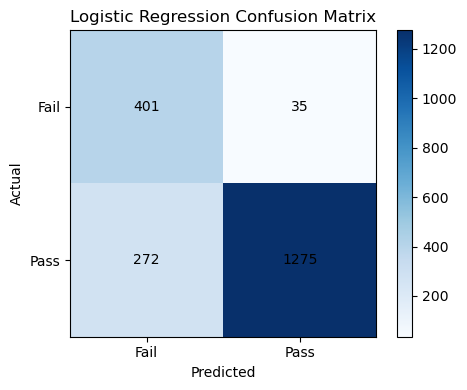


SVM
Accuracy: 0.8799798285426123

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.66      0.71       436
           1       0.91      0.94      0.92      1547

    accuracy                           0.88      1983
   macro avg       0.84      0.80      0.82      1983
weighted avg       0.88      0.88      0.88      1983

Confusion Matrix:
 [[ 287  149]
 [  89 1458]]


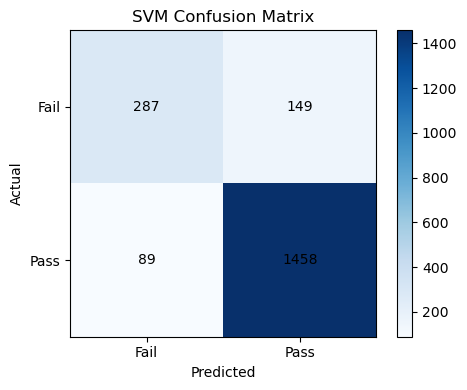


Random Forest
Accuracy: 0.8724155320221886

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.66      0.69       436
           1       0.91      0.93      0.92      1547

    accuracy                           0.87      1983
   macro avg       0.82      0.80      0.81      1983
weighted avg       0.87      0.87      0.87      1983

Confusion Matrix:
 [[ 288  148]
 [ 105 1442]]


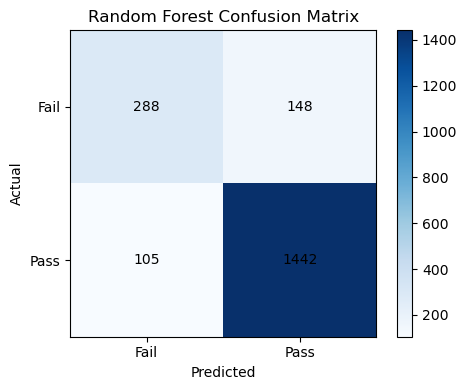

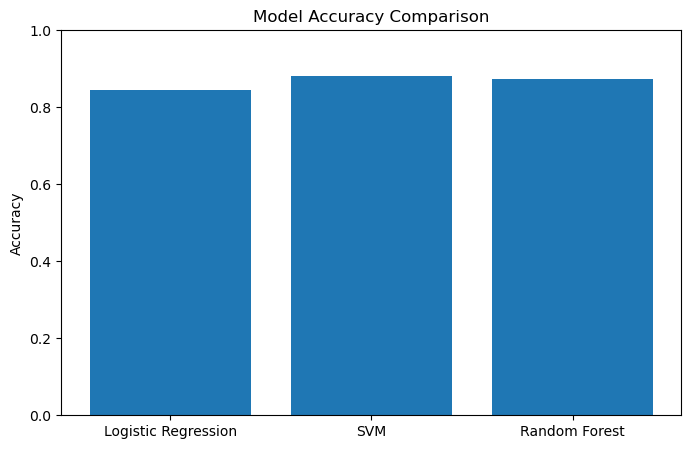

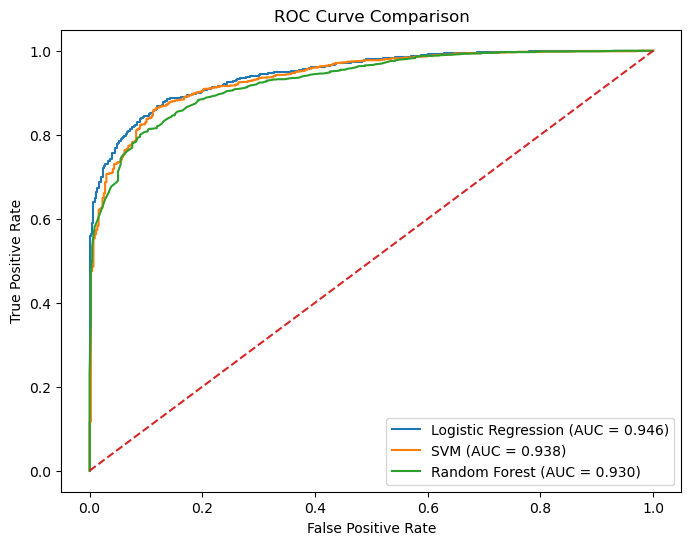


Feature Importance (Logistic Regression Coefficients):
Hours_Studied: 2.212623273800894
Attendance: 2.985890945815165
Sleep_Hours: 0.01347009497939675
Previous_Scores: 0.8557585154081752
Tutoring_Sessions: 0.8344171339695027
Physical_Activity: 0.30925181315888667
Intercept: 2.115836925724029


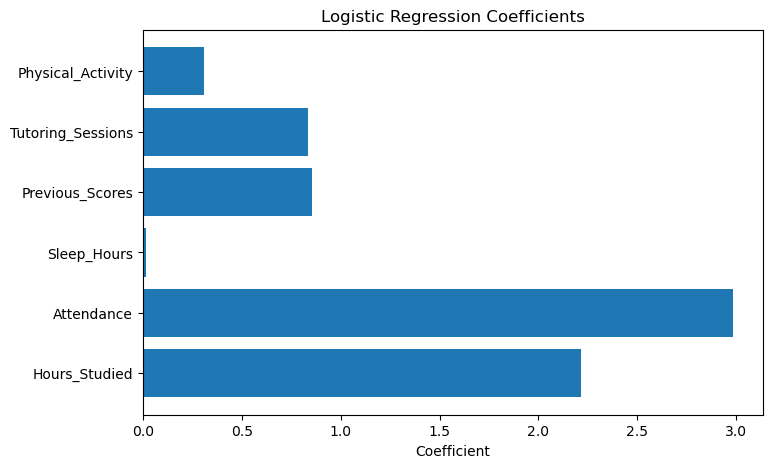


Feature Importance (Random Forest):
Hours_Studied: 0.2574414761089959
Attendance: 0.407493485015116
Sleep_Hours: 0.0656444959687628
Previous_Scores: 0.15338222058399048
Tutoring_Sessions: 0.061917501707181
Physical_Activity: 0.05412082061595388


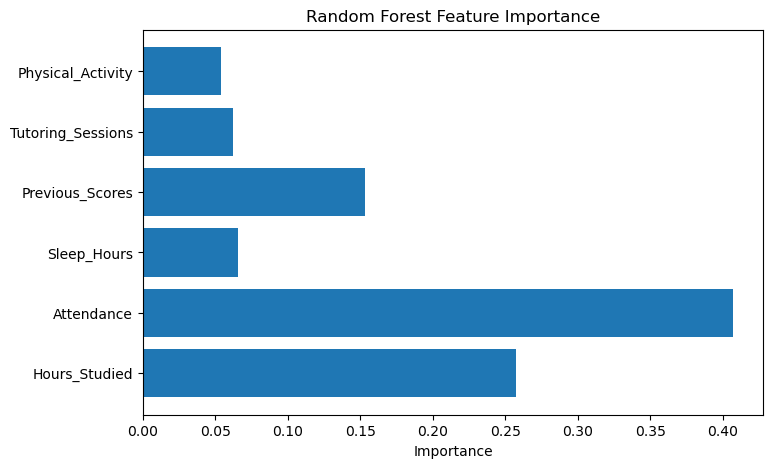

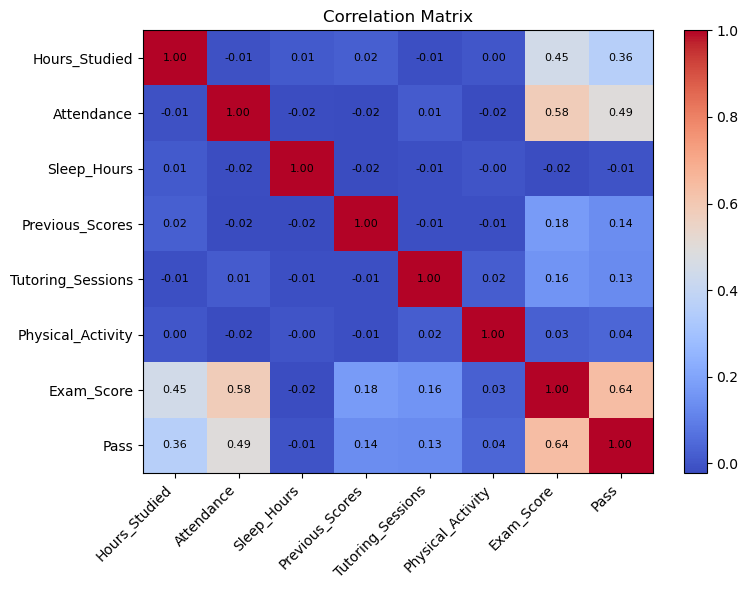

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    classification_report,
    roc_curve,
    auc
)


# Load dataset

df = pd.read_csv("dataset1_cleaned_numeric.csv")


# Create Pass/Fail column
# Pass = 1 if Exam_Score >= 65
# Fail = 0 if Exam_Score < 65

df["Pass"] = (df["Exam_Score"] >= 65).astype(int)

# Optional: save altered dataset
Altered_path = "C:/Users/User/Machine/Jupyter file/Supervised learning/dataset1_cleaned_altered.csv"
df.to_csv(Altered_path, index=False)


# Features and target

X = df.drop(["Exam_Score", "Pass"], axis=1)
y = df["Pass"]

print("Class distribution:")
print(y.value_counts())


# Train/test split

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


# Scale features
# Logistic Regression and SVM need scaling


scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)



# Train models

log_model = LogisticRegression(class_weight="balanced", random_state=42, max_iter=2000)
svm_model = SVC(kernel="rbf", C=1, probability=True, random_state=42)
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)

log_model.fit(x_train_scaled, y_train)
svm_model.fit(x_train_scaled, y_train)
rf_model.fit(x_train, y_train)


# Predictions

threshold = 0.6

log_prob = log_model.predict_proba(x_test_scaled)[:, 1]
log_pred = (log_prob >= threshold).astype(int)

svm_prob = svm_model.predict_proba(x_test_scaled)[:, 1]
svm_pred = svm_model.predict(x_test_scaled)

rf_prob = rf_model.predict_proba(x_test)[:, 1]
rf_pred = rf_model.predict(x_test)


# Evaluation

models = {
    "Logistic Regression": (log_pred, log_prob),
    "SVM": (svm_pred, svm_prob),
    "Random Forest": (rf_pred, rf_prob)
}

accuracies = []
model_names = []

for name, (pred, prob) in models.items():
    print("\n" + "="*50)
    print(name)
    print("="*50)

    acc = accuracy_score(y_test, pred)
    print("Accuracy:", acc)
    print("\nClassification Report:\n", classification_report(y_test, pred))

    cm = confusion_matrix(y_test, pred)
    print("Confusion Matrix:\n", cm)

    accuracies.append(acc)
    model_names.append(name)

    # Confusion matrix plot
    plt.figure(figsize=(5, 4))
    plt.imshow(cm, cmap="Blues")
    plt.title(f"{name} Confusion Matrix")
    plt.colorbar()
    plt.xticks([0, 1], ["Fail", "Pass"])
    plt.yticks([0, 1], ["Fail", "Pass"])

    for i in range(len(cm)):
        for j in range(len(cm[0])):
            plt.text(j, i, cm[i][j], ha="center", va="center")

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()


# Accuracy comparison bar chart

plt.figure(figsize=(8, 5))
plt.bar(model_names, accuracies)
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.show()


# ROC Curves

plt.figure(figsize=(8, 6))

for name, (pred, prob) in models.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


# Logistic Regression Coefficients

print("\nFeature Importance (Logistic Regression Coefficients):")
for feature, coef in zip(X.columns, log_model.coef_[0]):
    print(f"{feature}: {coef}")

print("Intercept:", log_model.intercept_[0])

# Logistic coefficient plot
plt.figure(figsize=(8, 5))
plt.barh(X.columns, log_model.coef_[0])
plt.xlabel("Coefficient")
plt.title("Logistic Regression Coefficients")
plt.show()


# Random Forest Feature Importance

print("\nFeature Importance (Random Forest):")
for feature, importance in zip(X.columns, rf_model.feature_importances_):
    print(f"{feature}: {importance}")

plt.figure(figsize=(8, 5))
plt.barh(X.columns, rf_model.feature_importances_)
plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")
plt.show()


# Correlation Matrix (no seaborn)

corr = df.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
plt.imshow(corr, cmap="coolwarm", aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()